# NASA CC3
this notebook shows the poles calculation of the NASA CC3 compressor. The problem is completely described in the section 5.6.1 of Spakovszky PhD thesis.
This version makes use only of functions.py. Another version, using the classes implementation will follow

### import 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from spakovszky.src.functions import *

### input data

In [2]:
mdot = 4.54  # mass flow rate
PR = 4  # pressure ratio impeller and vaned diffuser
Corr_speed = 21789 * 2 * np.pi / 60  # standard day corrected speed
U2 = 492  # exit tip speed
Nbl = 15  # impeller blades
Nvd = 24  # vaned diffuser blades
Nspl = 15  # splitter blades
Nspl = 15  # splitter blades
beta2 = -50 * np.pi / 180  # backsweep at exit of blades
R1t = 105 * 1e-3  # inlet tip radius
blade_height_1 = 64 * 1e-3  # inlet blade height
R2 = 215.5 * 1e-3  # inlet tip radius
blade_height_1 = 17 * 1e-3  # exit blade height
R3 = R2 * 1.078  # LE radius of vaned diffuser
div_angle = 7.8 * np.pi / 180  # divergence angle of vane blades
R4 = 181.5 * 1e-3  # diffuser outlet radius
s_i = 1.3064  # gas path length in impeller
s_dif = 1.1187  # diffuser path length
lambda_i = 1.1508  # impeller inertia factor
lambda_d = 0.8518  # diffuser inertia factor

# STATIONS
x0 = -1.5957  # non dimensionalized by impeller exit radius
r0 = 0.7483
A0 = 4.1276  # area at station 0 non-dimensionalized by impeller exit radius
x1 = 0
r1 = 0.3533
A1 = 0.6276
x2 = 0
r2 = 1.0
A2 = 0.4965
x3 = 0
r3 = 1.0779
A3 = 0.5330
x4 = 0
r4 = 1.6838
A4 = 0.8339
x5 = 0.2211
r5 = 1.8428
A5 = 0.8189

### interpolation loss function $L^{ss}$ of the impeller and diffuser
from data point visible in the thesis, interpolate the loss functions with $3^{rd}$ order polynomials

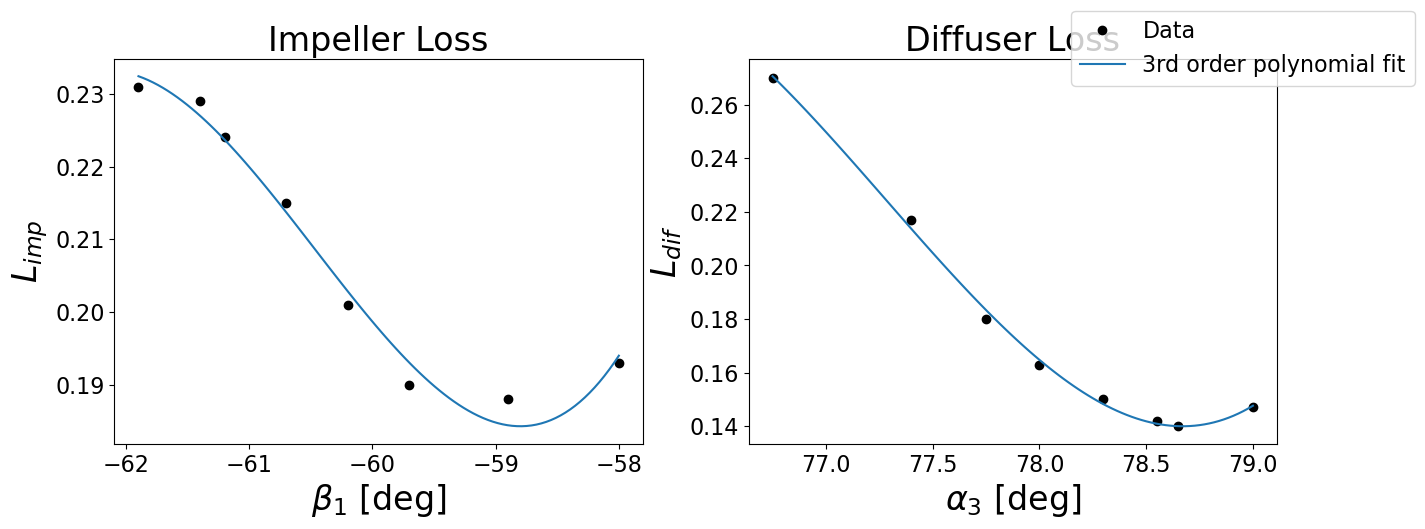

In [3]:
beta1_data = np.array([-61.9, -61.4, -61.2, -60.7, -60.2, -59.7, -58.9, -58]) * np.pi / 180  # inlet relative flow angle
Loss_i_data = np.array([0.231, 0.229, 0.224, 0.215, 0.201, 0.19, 0.188, 0.193])  # loss
z_coeff_i = np.polyfit(beta1_data, Loss_i_data, 3)
beta1 = np.linspace(beta1_data[0], beta1_data[-1], 100)
Loss_i = np.polyval(z_coeff_i, beta1)

alpha3_data = np.array([76.75, 77.4, 77.75, 78, 78.3, 78.55, 78.65, 79]) * np.pi / 180  # inlet relative flow angle
Loss_d_data = np.array([0.27, 0.217, 0.18, 0.163, 0.15, 0.142, 0.14, 0.147])  # loss
z_coeff_d = np.polyfit(alpha3_data, Loss_d_data, 3)
alpha3 = np.linspace(alpha3_data[0], alpha3_data[-1], 100)
Loss_d = np.polyval(z_coeff_d, alpha3)

# plot the loss functions
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(beta1_data * 180 / np.pi, Loss_i_data, 'ko', label='Data')
ax[0].plot(beta1 * 180 / np.pi, Loss_i, label='3rd order polynomial fit')
ax[1].plot(alpha3_data * 180 / np.pi, Loss_d_data, 'ko')
ax[1].plot(alpha3 * 180 / np.pi, Loss_d)
ax[0].set_title('Impeller Loss')
ax[0].set_xlabel(r'$\beta_1$' + ' [deg]')
ax[0].set_ylabel(r'$L_{imp}$')
ax[1].set_title('Diffuser Loss')
ax[1].set_xlabel(r'$\alpha_3$' + ' [deg]')
ax[1].set_ylabel(r'$L_{dif}$')
fig.legend()

### operating point estimation
estimation of the operating point used by Spakovszky

In [4]:
rho = 1.014  # my assumption on air density
U_ref = U2  # reference velocity, it should be inlet tip speed
R_ref = R2  # the reference length 
V2r_op = 0.149 * U_ref
mdot_op = A2 * R_ref ** 2 * rho * V2r_op
V1_x_op = mdot_op / (A1 * R_ref ** 2) / rho
U1_op = U_ref * r1 / r2
beta1_op = -np.arctan(U1_op / V1_x_op)
beta1_op_deg = beta1_op * 180 / np.pi

W2_op = V2r_op / np.sin(beta2)
alpha3_op = np.arctan((U2 - W2_op * np.sin(beta2)) / V2r_op)
alpha3_op_deg = alpha3_op * 180 / np.pi

Vx1 = V1_x_op / U_ref
Vx2 = 0
Vx3 = 0
Vx4 = mdot_op / (A4 * R_ref ** 2) / rho / U_ref  # from continuity (assuming turning at point 4)
Vx5 = Vx4 * A4 / A5
Vy1 = 0  # 0 prerotation
Vy2 = (U2 - V2r_op / np.tan(beta2)) / U_ref
Vy3 = Vy2 * r2 / r3
Vy4 = Vy3 * r3 / r4  # completely guessed, based on conservation of angular momentum
Vy5 = Vy4 * r4 / r5  # completely guessed, based on conservation of angular momentum
Vr1 = 0
Vr2 = V2r_op / U_ref
Vr3 = Vr2 * (r2 / r3)  
Vr4 = mdot_op / (A4 * R_ref ** 2) / rho / U_ref  # from continuity
Vr5 = 0

alfa3 = np.arctan(Vy3 / Vr3)
beta3 = beta2
alfa4 = np.arctan(Vy4 / Vr4)
rho4 = rho
rho3 = rho
dLd_dTana = 0  # visual
Q = 2 * np.pi * r2 * Vr2  # non dimensional source term at station 2
GAMMA = 2 * np.pi * r2 * Vy2  # non dimensional circulation term at station 2
alfa1 = 0
U1 = U2 * r1 / r2 / U_ref
beta1 = np.arctan(-U1 / Vx1)
rho1 = rho
rho2 = rho
dLi_dTanb = 0

### system transfer function
assemble the system transfer function for the NASA CC3 compressor

In [5]:
def centrifugal_vaned(s, n, theta=0):
    m1 = np.linalg.inv(Tax_n(x4, s, n, Vx4, Vy4, theta=theta))
    m2 = Bdif_n(s, n, Vr3, Vr4, Vy3, Vy4, alfa3, beta3, alfa4, r3, r4, rho3, rho4, A3, A4, s_dif, dLd_dTana, 0, 0)
    m3 = Bvlsd_n(s, n, r2, r3, r2, Q, GAMMA, 0)
    m4 = Bimp_n(s, n, Vx1, Vr2, Vy1, Vy2, alfa1, beta1, beta2, r1, r2, rho1, rho2, A1, A2, s_i, dLi_dTanb, 0, 0)
    m5 = Tax_n(x1, s, n, Vx1, Vy1, theta=theta)
    m6 = np.linalg.multi_dot([m1, m2, m3, m4, m5])
    EC = np.array([[(-s / n - Vx5 - 1j * Vy5) * np.exp(n * x5), (s / n - Vx5 + 1j * Vy5) * np.exp(-n * x5), 0]])
    IC = np.array([[0, 1, 0],
                   [0, 0, 1]])
    Y = np.concatenate((np.matmul(EC, m6), IC))
    return np.linalg.det(Y)

### specify poles research settings

In [6]:
domain = [-3.5, 0.5, -2.5, 6]  # rotation and growth factor limits
grid = [2, 2]  # quadrants of the research
n = np.arange(1, 7)  # harmonics to compute

### find the poles

/opt/anaconda3/envs/unsflow/lib/python3.9/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/opt/anaconda3/envs/unsflow/lib/python3.9/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Text(0.5, 1.0, 'Root locus')

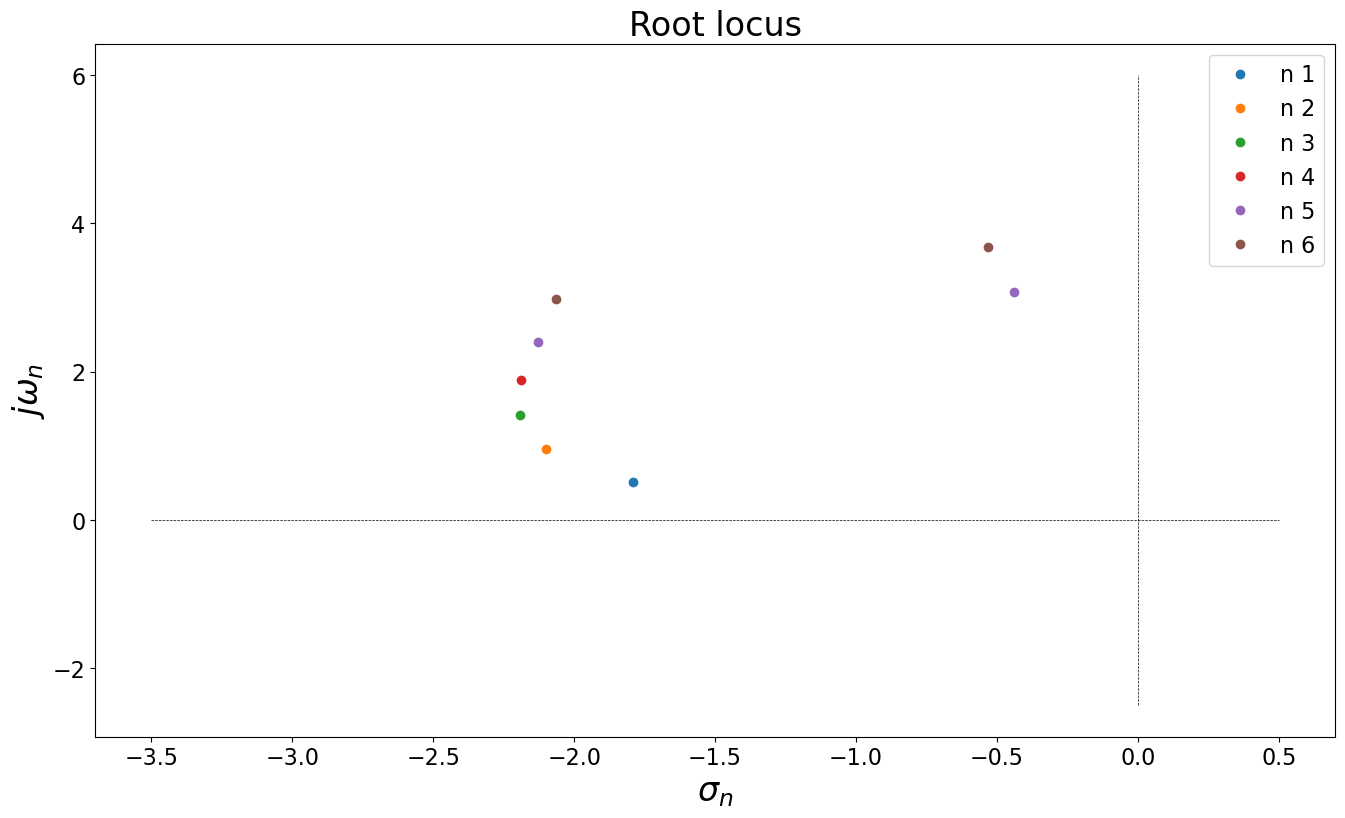

In [7]:
poles = {}  # dict contaning the poles
plt.figure(figsize=(16, 9))
for nn in n:
    poles[nn] = Shot_Gun(centrifugal_vaned, domain, grid, n=nn, attempts=10)
    plt.plot(poles[nn].real, -poles[nn].imag, 'o', label='n ' + str(nn))
real_axis_x = np.linspace(domain[0], domain[1], 100)
real_axis_y = np.zeros(len(real_axis_x))
imag_axis_y = np.linspace(domain[2], domain[3], 100)
imag_axis_x = np.zeros(len(imag_axis_y))
plt.plot(real_axis_x, real_axis_y, '--k', linewidth=0.5)
plt.plot(imag_axis_x, imag_axis_y, '--k', linewidth=0.5)
# plt.xlim([domain[0],domain[1]])
# plt.ylim([domain[2],domain[3]])
plt.legend()
plt.xlabel(r'$\sigma_{n}$')
plt.ylabel(r'$j \omega_{n}$')
plt.title('Root locus')
# plt.savefig(path+'/poles_rotor_stator_deltax_03.png')